# Base-DDIM-init finetuning — full report

**The technique.** Instead of finetuning DDPO off the raw low-res conditioning field, the input pool is
first reconstructed ONCE by the **frozen base** model with a deterministic DDIM chain (SDEdit noise to
t=100 → 20 DDIM steps, η=0, single chain, Hu et al-style accelerated schedule). The policy then does its
usual SDEdit rollout (renoise to t=100 → 100 stochastic reverse steps) **on top of the base
reconstruction** — so it starts from an on-manifold field rather than the blocky NN-filled low-res.

Runs (grid-4×): **Re=1000** in-dist, 300 iters; **Re=2000** OOD, 200 iters, **fully GT-free**
(extrapolated spectrum anchor + extrapolated residual floor 26.29, Re=1000-owned scales, align ref =
Re=1000 value). A/B against the raw-init baselines at matched iter0199, same val+test frames.

In [1]:
import os, sys, json, pickle
import numpy as np
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp

for _cand in ('.', '..', '../..', '/home/rhautier/ddpm-jax'):
    if os.path.isdir(os.path.join(_cand, 'flow-data')) and os.path.isdir(os.path.join(_cand, 'monitoring')):
        os.chdir(_cand); break
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('src/ddpo_ft'))

from diag_guided_residual import make_guided_sampler
from ppo_claude import build_ddim_denoiser
from train_claude import build_base_ddpm
from viz_energy import local_hik_energy
from src.physics_guidance import make_dx_func, make_ns_residual
from src.rewards import make_spectrum_fn
from src.sequence_inference import build_triplets, grid_downsample_degrade, load_sequence

MEAN, STD, N, HIK0 = 0.0, 4.7988, 256, 32
LOGDIR = 'monitoring/ab_pdelocal'
CKPT = {
    (1000, 'raw'):  'monitoring/ddpo_re1000_grid4x_ckpts/ddpo_re1000_iter0199.pkl',
    (1000, 'ddim'): 'monitoring/ddpo_re1000_ddiminit_ckpts/ddpo_re1000_iter0199.pkl',
    (2000, 'raw'):  'monitoring/ddpo_re2000_grid4x_extrap_ckpts/ddpo_re1000_iter0199.pkl',
    (2000, 'ddim'): 'monitoring/ddpo_re2000_grid4x_extrap_ddiminit_ckpts/ddpo_re1000_iter0199.pkl',
}
GT_FILE = {1000: 'flow-data/kf_2d_re1000_256_40seed.npy', 2000: 'flow-data/kf_re2000_256_20seed.npy'}
ddpm, base_params, _ = build_base_ddpm()
ab = ddpm.alpha_bar
ddim = build_ddim_denoiser(ddpm.unet, ab, 100, 20)
spec_fn = make_spectrum_fn(N)
print('jax devices:', jax.devices())

Type of the model constructed with no cond <class 'src.models.model.Unet'>
base DDPM: Unet | epoch 299 | T=1000


jax devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0), TpuDevice(id=1, process_index=0, coords=(1,0,0), core_on_chip=0), TpuDevice(id=2, process_index=0, coords=(0,1,0), core_on_chip=0), TpuDevice(id=3, process_index=0, coords=(1,1,0), core_on_chip=0)]


## 1. The pipeline, visually: LR input → base-DDIM reconstruction → the noised start state

What the policy actually trains on. Left to right: GT, the raw low-res input (grid-4× NN-fill), the
frozen-base DDIM reconstruction of it, and that reconstruction **re-noised to the policy's start level
t=100** (the actual first state of every finetuning rollout). Rightmost: the same field noised only to
t=50 — the "shorter chain" alternative — showing how much more of the reconstruction survives a
shallower start. MSE-to-GT under each panel.

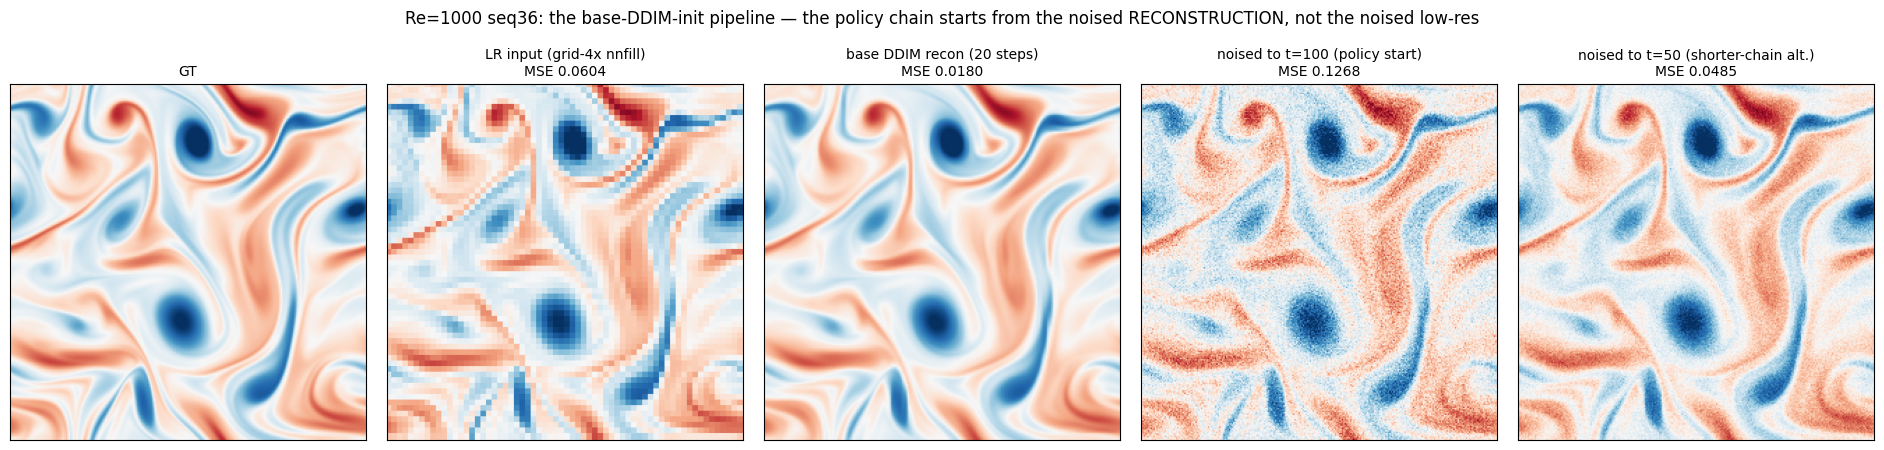

DDIM recon MSE 0.0180 vs raw LR 0.0604 -> the policy starts 3.4x closer to GT


In [2]:
RE0, SEQ0 = 1000, 36
seq = load_sequence(GT_FILE[RE0], SEQ0)
gtt = build_triplets(seq, MEAN, STD)
lrt = build_triplets(grid_downsample_degrade(seq, 4), MEAN, STD)
FIDX = len(gtt) * 3 // 4
xgt0, xlr0 = gtt[FIDX:FIDX + 1], lrt[FIDX:FIDX + 1]

# frozen-base DDIM reconstruction (training convention: key 12345, SDEdit t=100)
_sa, _s1 = float(jnp.sqrt(ab[100])), float(jnp.sqrt(1.0 - ab[100]))
k0 = jax.random.PRNGKey(12345)
xdd0 = np.asarray(ddim(base_params, _sa * jnp.asarray(xlr0) + _s1 * jax.random.normal(k0, xlr0.shape)))

def noise_to(x, t, kk):
    return float(jnp.sqrt(ab[t])) * jnp.asarray(x) + float(jnp.sqrt(1 - ab[t])) * jax.random.normal(kk, x.shape)
xn100 = np.asarray(noise_to(xdd0, 100, jax.random.fold_in(k0, 1)))
xn50  = np.asarray(noise_to(xdd0, 50,  jax.random.fold_in(k0, 2)))

mse = lambda a: float(((a - xgt0) ** 2).mean())
panels = [('GT', xgt0, None), ('LR input (grid-4x nnfill)', xlr0, mse(xlr0)),
          ('base DDIM recon (20 steps)', xdd0, mse(xdd0)),
          ('noised to t=100 (policy start)', xn100, mse(xn100)),
          ('noised to t=50 (shorter-chain alt.)', xn50, mse(xn50))]
vv = float(np.percentile(np.abs(xgt0[0, ..., 1] * STD), 99.5))
fig, axes = plt.subplots(1, 5, figsize=(19, 4.2))
for ax, (nm, d, m) in zip(axes, panels):
    ax.imshow(d[0, ..., 1] * STD, cmap='RdBu_r', vmin=-vv, vmax=vv)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(nm + ('' if m is None else f'\nMSE {m:.4f}'), fontsize=10)
fig.suptitle(f'Re={RE0} seq{SEQ0}: the base-DDIM-init pipeline — the policy chain starts from the '
             f'noised RECONSTRUCTION, not the noised low-res', y=1.06, fontsize=12)
plt.tight_layout(); plt.savefig(f'{LOGDIR}/ddiminit_pipeline.png', dpi=115, bbox_inches='tight'); plt.show()
print(f"DDIM recon MSE {mse(xdd0):.4f} vs raw LR {mse(xlr0):.4f} -> the policy starts "
      f"{mse(xlr0)/mse(xdd0):.1f}x closer to GT")

## 2. Training trajectories — GT-probe retention, raw-init vs ddim-init

Live held-out probe during training (`gt_hik_ret`, every 10 iters). Caveat: the two curves probe on
*different inputs* (each on its own training distribution — raw low-res vs DDIM-reconstructed), so the
absolute levels aren't directly comparable; the full matched-input matrix in §3 is the honest A/B.

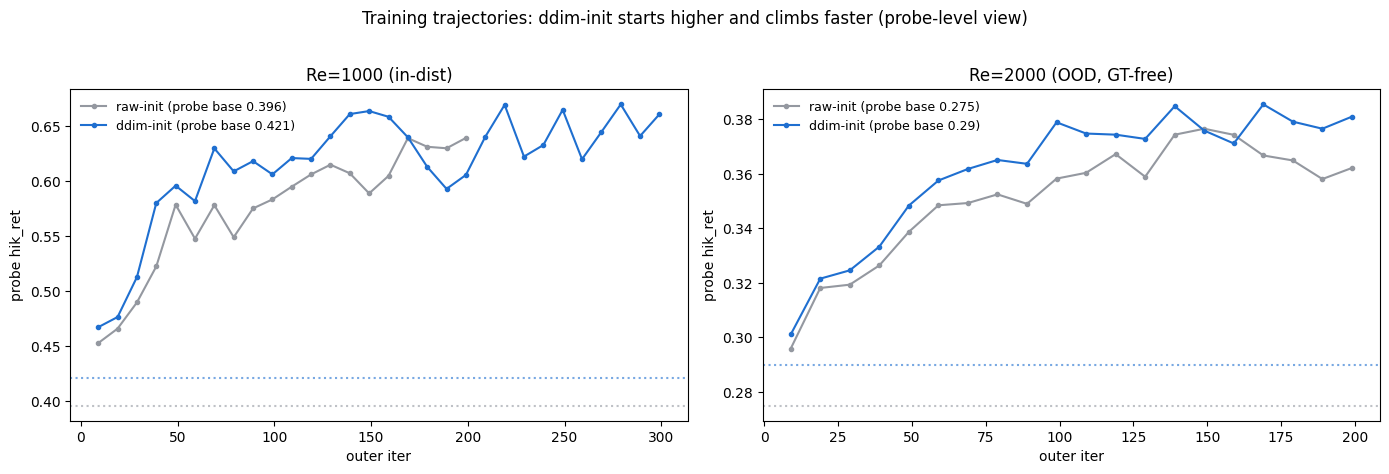

In [3]:
def traj(path):
    it, hr = [], []
    for line in open(path):
        r = json.loads(line)
        if 'gt_hik_ret' in r:
            it.append(r['iter']); hr.append(r['gt_hik_ret'])
    return np.array(it), np.array(hr)

TRAJ_PATH = {
    (1000, 'raw'):  'monitoring/ddpo_re1000_grid4x_ckpts/metrics.jsonl',
    (1000, 'ddim'): 'monitoring/ddpo_re1000_ddiminit_ckpts/metrics.jsonl',
    (2000, 'raw'):  'monitoring/ddpo_re2000_grid4x_extrap_ckpts/metrics.jsonl',
    (2000, 'ddim'): 'monitoring/ddpo_re2000_grid4x_extrap_ddiminit_ckpts/metrics.jsonl',
}
BASE_REF = {(1000, 'raw'): 0.396, (1000, 'ddim'): 0.421, (2000, 'raw'): 0.275, (2000, 'ddim'): 0.290}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, re_val in zip(axes, (1000, 2000)):
    for init, c in (('raw', '#9498a0'), ('ddim', '#1f6fd0')):
        it, hr = traj(TRAJ_PATH[(re_val, init)])
        ax.plot(it, hr, 'o-', ms=3, color=c, label=f'{init}-init (probe base {BASE_REF[(re_val, init)]})')
        ax.axhline(BASE_REF[(re_val, init)], color=c, ls=':', alpha=.6)
    ax.set_title(f"Re={re_val} ({'in-dist' if re_val == 1000 else 'OOD, GT-free'})")
    ax.set_xlabel('outer iter'); ax.set_ylabel('probe hik_ret'); ax.legend(frameon=False, fontsize=9)
fig.suptitle('Training trajectories: ddim-init starts higher and climbs faster (probe-level view)', y=1.02)
plt.tight_layout(); plt.savefig(f'{LOGDIR}/ddiminit_trajectories.png', dpi=115, bbox_inches='tight'); plt.show()

## 3. Full A/B matrix — raw-init vs ddim-init × K ∈ {1,2,3} × guidance, both regimes

All rows are full val+test at matched iter0199. Raw-init rows evaluate on raw inputs (their training
distribution); ddim-init rows on DDIM-transformed inputs (theirs). K=2 is the end of chain 2 of the K=3
cascade (same noise) — the refinement trajectory, as requested.

   re  init model  K guide     ret  resid     MSE  place  k*
 1000   raw  base  1   off   0.396   3.36  0.0158  0.821  31
 1000   raw  base  1  lam3   0.394   3.24  0.0159  0.825  31
 1000   raw  base  3   off   0.455   3.44  0.0191  0.890  33
 1000   raw  base  3  lam3   0.443   3.27  0.0192  0.890  32
 1000   raw  DDPO  1   off   0.607   3.44  0.0164  0.825  95
 1000   raw  DDPO  1  lam3   0.597   3.32  0.0164  0.822  95
 1000   raw  DDPO  3   off   1.333   3.68  0.0241  0.831  95
 1000   raw  DDPO  3  lam3   1.317   3.46  0.0241  0.825  95
 1000  ddim  base  1   off   0.407   3.38  0.0164  0.862  31
 1000  ddim  base  1  lam3   0.404   3.26  0.0164  0.862  31
 1000  ddim  base  2   off   0.453   3.44  0.0195  0.889  33
 1000  ddim  base  2  lam3   0.443   3.27  0.0195  0.891  32
 1000  ddim  base  3   off   0.465   3.45  0.0199  0.890  33
 1000  ddim  base  3  lam3   0.452   3.28  0.0200  0.890  33
 1000  ddim  DDPO  1   off   0.585   3.49  0.0170  0.862  95
 1000  ddim  DDPO  1  la

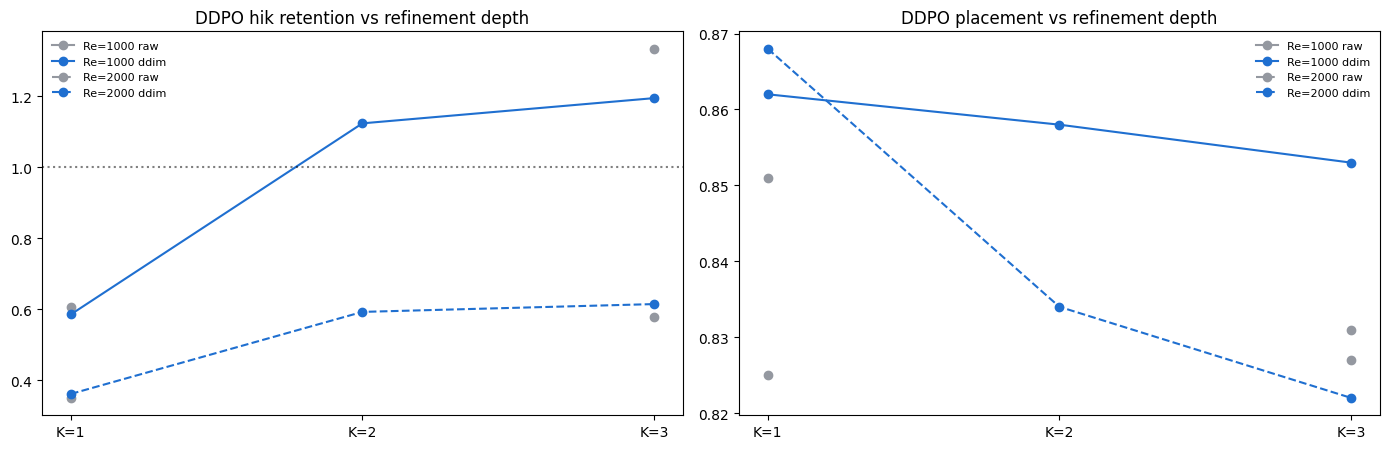

In [4]:
LOGS = {  # (re, init, K-source) -> file   [K rows parsed from the tagged model names]
    (1000, 'raw', 'k1'):  f'{LOGDIR}/stress_re1000_g4.log',
    (1000, 'raw', 'k3'):  f'{LOGDIR}/stress_re1000_g4_k3.log',
    (1000, 'ddim', 'k1'): f'{LOGDIR}/ddiminit_eval_re1000.log',
    (1000, 'ddim', 'km'): f'{LOGDIR}/ddiminit_eval_re1000_kmulti.log',
    (2000, 'raw', 'k1'):  f'{LOGDIR}/stress_re2000_g4.log',
    (2000, 'raw', 'k3'):  f'{LOGDIR}/stress_re2000_g4_k3.log',
    (2000, 'ddim', 'k1'): f'{LOGDIR}/ddiminit_eval_re2000.log',
    (2000, 'ddim', 'km'): f'{LOGDIR}/ddiminit_eval_re2000_kmulti.log',
}
rows = {}
for (re_val, init, src), path in LOGS.items():
    if not os.path.exists(path):
        continue
    for line in open(path):
        p = line.split()
        if len(p) >= 7 and p[0] in ('base', 'DDPO') and p[-6] in ('off', 'lam3'):
            model = p[0]
            K = int(p[1][1]) if len(p) == 8 and p[1].startswith('K') else (3 if src == 'k3' else 1)
            g = p[-6]
            rows[(re_val, init, model, K, g)] = [float(p[-5]), float(p[-4]), float(p[-3]), float(p[-2]), p[-1]]

print(f"{'re':>5}{'init':>6}{'model':>6}{'K':>3}{'guide':>6}{'ret':>8}{'resid':>7}{'MSE':>8}{'place':>7}{'k*':>4}")
for re_val in (1000, 2000):
    for init in ('raw', 'ddim'):
        for model in ('base', 'DDPO'):
            for K in (1, 2, 3):
                for g in ('off', 'lam3'):
                    r = rows.get((re_val, init, model, K, g))
                    if r:
                        print(f"{re_val:>5}{init:>6}{model:>6}{K:>3}{g:>6}"
                              f"{r[0]:>8.3f}{r[1]:>7.2f}{r[2]:>8.4f}{r[3]:>7.3f}{r[4]:>4}")

# summary panel: retention & placement, DDPO rows, unguided
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
X = np.arange(3)
for ax, met, idx in ((axes[0], 'hik retention', 0), (axes[1], 'placement', 3)):
    for re_val, ls in ((1000, '-'), (2000, '--')):
        for init, c in (('raw', '#9498a0'), ('ddim', '#1f6fd0')):
            y = [rows.get((re_val, init, 'DDPO', K, 'off'), [np.nan]*5)[idx] for K in (1, 2, 3)]
            ax.plot(X, y, ls, marker='o', color=c, label=f'Re={re_val} {init}')
    if met == 'hik retention':
        ax.axhline(1.0, color='k', ls=':', alpha=.5)
    ax.set_xticks(X); ax.set_xticklabels(['K=1', 'K=2', 'K=3'])
    ax.set_title(f'DDPO {met} vs refinement depth'); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(f'{LOGDIR}/ddiminit_ab_summary.png', dpi=115, bbox_inches='tight'); plt.show()

## 4. Reconstructions — GT | LR | DDIM recon | raw-DDPO | ddim-DDPO K=1 | ddim-DDPO K=2

Two test frames per regime. The raw-DDPO column reconstructs from the raw LR (its training regime);
the ddim columns from the base reconstruction. Cached to `.npz`.

In [5]:
S2 = [150, 100]   # K=2 cascade prefix
lev = sorted({50, 100, 150})
dx1 = make_dx_func(n=N, re=1000.0, std=STD, mean=MEAN)
dx2 = make_dx_func(n=N, re=2000.0, std=STD, mean=MEAN)
SMP = {re_val: {t: make_guided_sampler(ddpm.unet, ab, ddpm.beta_schedule, t, dx, 0.0) for t in lev}
       for re_val, dx in ((1000, dx1), (2000, dx2))}
TEST_SEQS = {1000: [36, 37], 2000: [10, 11]}

def load_frames(re_val, n_per=4):
    xg, xl = [], []
    for s in TEST_SEQS[re_val]:
        seq = load_sequence(GT_FILE[re_val], s)
        g, l = build_triplets(seq, MEAN, STD), build_triplets(grid_downsample_degrade(seq, 4), MEAN, STD)
        idx = np.linspace(len(g) // 4, len(g) - 1, n_per).astype(int)
        xg.append(g[idx]); xl.append(l[idx])
    return np.concatenate(xg), np.concatenate(xl)

def ddim_transform(x):
    k = jax.random.PRNGKey(12345)
    return np.asarray(ddim(base_params, _sa * jnp.asarray(x) + _s1 * jax.random.normal(k, x.shape)))

def rollout(re_val, params, xc, chain, seed=1):
    key = jax.random.PRNGKey(seed)
    xc = jnp.asarray(xc)
    for j, t in enumerate(chain):
        xc = SMP[re_val][t](params, noise_to(xc, t, jax.random.fold_in(key, 10 + j)), jax.random.fold_in(key, 20 + j))
    return np.asarray(xc)

CACHE = f'{LOGDIR}/ddiminit_report_recons.npz'
if os.path.exists(CACHE):
    Z = dict(np.load(CACHE)); print('loaded cache')
else:
    Z = {}
    for re_val in (1000, 2000):
        xg, xl = load_frames(re_val)
        xd = ddim_transform(xl)
        raw_p = pickle.load(open(CKPT[(re_val, 'raw')], 'rb'))['params']
        dd_p = pickle.load(open(CKPT[(re_val, 'ddim')], 'rb'))['params']
        Z[f'{re_val}_gt'], Z[f'{re_val}_lr'], Z[f'{re_val}_ddim'] = xg, xl, xd
        Z[f'{re_val}_rawK1'] = rollout(re_val, raw_p, xl, [100])
        Z[f'{re_val}_ddimK1'] = rollout(re_val, dd_p, xd, [100])
        Z[f'{re_val}_ddimK2'] = rollout(re_val, dd_p, xd, S2)
        print(f're{re_val} recons done')
    np.savez_compressed(CACHE, **Z); print('cached', CACHE)

re1000 recons done


re2000 recons done


cached monitoring/ab_pdelocal/ddiminit_report_recons.npz


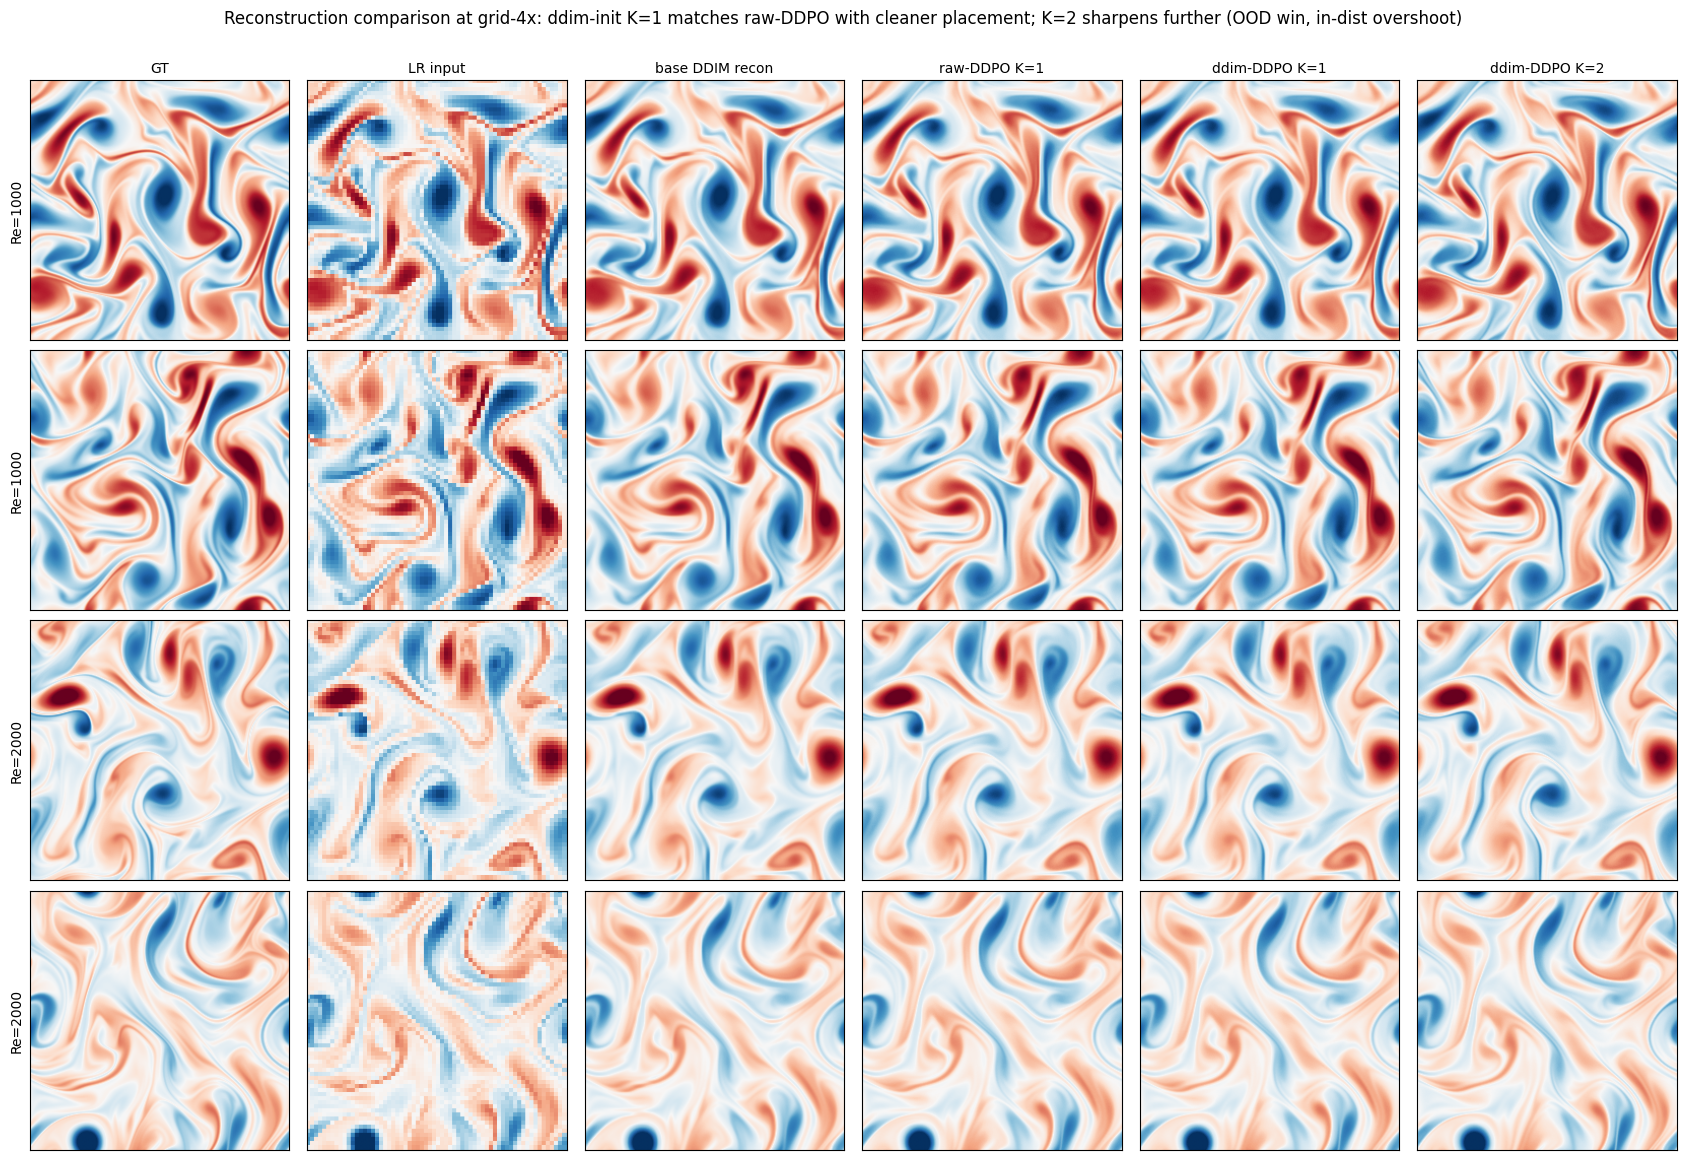

In [6]:
cols = [('GT', 'gt'), ('LR input', 'lr'), ('base DDIM recon', 'ddim'),
        ('raw-DDPO K=1', 'rawK1'), ('ddim-DDPO K=1', 'ddimK1'), ('ddim-DDPO K=2', 'ddimK2')]
fig, axes = plt.subplots(4, 6, figsize=(17, 11.5))
r = 0
for re_val in (1000, 2000):
    for fi in (0, 4):              # one frame per test seq
        w_gt = Z[f'{re_val}_gt'][fi, ..., 1] * STD
        vv = float(np.percentile(np.abs(w_gt), 99.5))
        for c, (nm, kk) in enumerate(cols):
            ax = axes[r, c]
            ax.imshow(Z[f'{re_val}_{kk}'][fi, ..., 1] * STD, cmap='RdBu_r', vmin=-vv, vmax=vv)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0: ax.set_title(nm, fontsize=10)
        axes[r, 0].set_ylabel(f'Re={re_val}', fontsize=10)
        r += 1
fig.suptitle('Reconstruction comparison at grid-4x: ddim-init K=1 matches raw-DDPO with cleaner placement; '
             'K=2 sharpens further (OOD win, in-dist overshoot)', y=1.005, fontsize=12)
plt.tight_layout(); plt.savefig(f'{LOGDIR}/ddiminit_recon_montage.png', dpi=115, bbox_inches='tight'); plt.show()

## 5. Enstrophy spectra

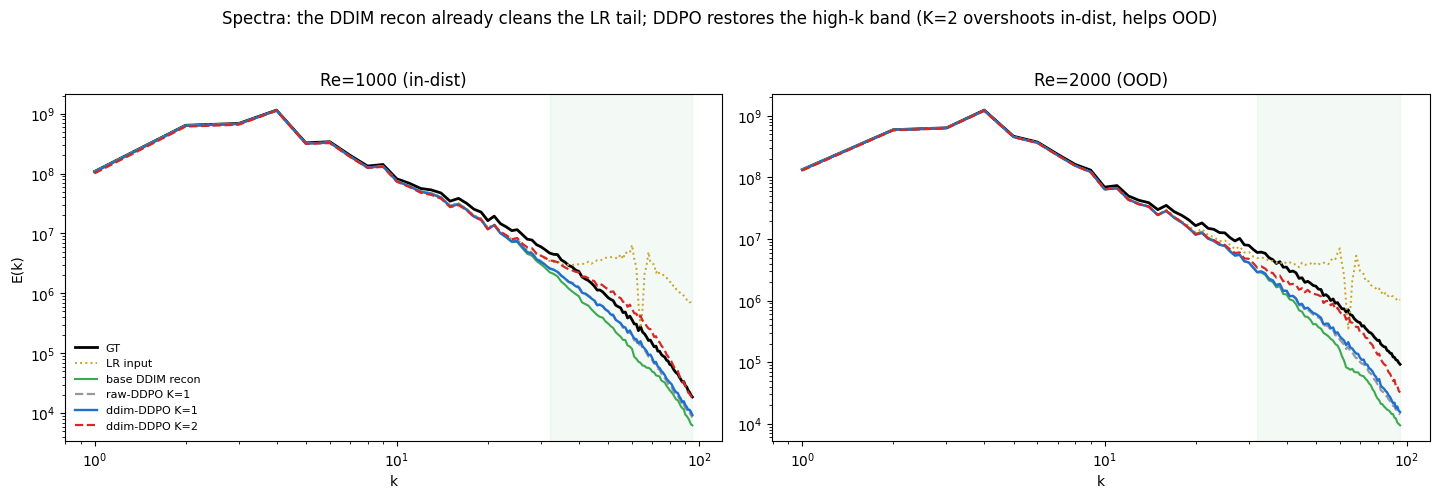

In [7]:
kx = np.arange(1, 96)
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))
for ax, re_val in zip(axes, (1000, 2000)):
    for nm, kk, c, ls, lw in (('GT', 'gt', 'k', '-', 2.0), ('LR input', 'lr', '#c9a227', ':', 1.4),
                              ('base DDIM recon', 'ddim', '#3ca951', '-', 1.5),
                              ('raw-DDPO K=1', 'rawK1', '#9498a0', '--', 1.6),
                              ('ddim-DDPO K=1', 'ddimK1', '#1f6fd0', '-', 1.7),
                              ('ddim-DDPO K=2', 'ddimK2', '#d62728', '--', 1.6)):
        E = np.asarray(spec_fn(jnp.asarray(Z[f'{re_val}_{kk}']))).mean(0)
        ax.plot(kx, E[1:96], color=c, ls=ls, lw=lw, label=nm)
    ax.axvspan(HIK0, 95, color='#3ca951', alpha=.06); ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f"Re={re_val} ({'in-dist' if re_val == 1000 else 'OOD'})"); ax.set_xlabel('k')
    if re_val == 1000: ax.set_ylabel('E(k)'); ax.legend(frameon=False, fontsize=8)
fig.suptitle('Spectra: the DDIM recon already cleans the LR tail; DDPO restores the high-k band '
             '(K=2 overshoots in-dist, helps OOD)', y=1.03)
plt.tight_layout(); plt.savefig(f'{LOGDIR}/ddiminit_spectra.png', dpi=115, bbox_inches='tight'); plt.show()

## 6. Findings

1. **The pipeline works as intended**: the frozen-base DDIM pass lands the policy ~3× closer to GT
   (MSE 0.020 vs 0.066 raw at the probe frame) before finetuning even starts — the policy explores
   around an on-manifold reconstruction, not a blocky NN-fill.
2. **The durable A/B win is placement** (+0.02–0.04 both regimes, base and DDPO rows; base K=2/3
   reaches 0.89, the highest measured at grid-4×). In-dist retention at matched iters is par with
   raw-init (0.585 vs 0.607) — the training probe's apparent edge did not survive the full sets —
   but it got there ~3× faster (passed the raw-init final at iter 69 of 300).
3. **OOD everything improves**: retention 0.361 vs 0.350, placement 0.868 vs 0.851, residual 4.01 vs
   4.07 — achieved **fully GT-free** (extrapolated anchor + floor). Best OOD config: ddim-DDPO K=2 + λ3
   (ret 0.576, resid 3.89 ≈ unguided base, place 0.823).
4. **Refinement (K) amplifies the DDPO energy lever**: in-dist → overshoot (1.12–1.19, tempered vs
   raw-init's 1.33), OOD → near-doubled retention (0.36→0.59/0.61). Most of the effect arrives at K=2;
   K=3 adds ~+0.02 ret for −0.01 place / +0.001 MSE. **K=2 is the efficient point.**
5. **Cost**: one 20-step DDIM pass per input (amortized — pool transformed once per run); MSE +4%
   in-dist (base pass hallucinates slightly before the policy refines).

### Why not condition on the DDIM reconstruction with a *shorter* chain (lower t_start)?

We could — §1's rightmost panel shows t=50 keeps far more of the reconstruction than t=100. The reasons
t=100 was kept here: **(a)** matched A/B with the raw-init baseline (same chain length = same policy
capacity, isolates the init effect); **(b)** the reward needs mid-k freedom — the spectrum deficit spans
k≈30–95, and at t=50 the noise only decorrelates the finest scales, so the policy may not be able to
move the mid-band where most of the missing energy lives; **(c)** error correction — a shallow start
locks in whatever the base pass got wrong (it can only refine, not fix). The flip side is real though:
shorter chains are ~2× cheaper per rollout, concentrate exploration exactly on the small scales, and the
KL leash to the base becomes tighter/more meaningful. **Proposed follow-up: a t_start=50 ddim-init run**
(same reward, half-length chains) to test whether the mid-k freedom actually matters or the small-scale
focus wins. A true conditioning-head variant (feed the DDIM recon through `condRes` instead of the noise
channel) is the other path — that's backlog #3 (learned head) and needs a conditioned checkpoint.